In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import joblib
import shap

In [6]:
crisis_labels = pd.read_csv("C:\\Users\\E15\\OneDrive\\Documents\\GitHub\\Financial-crisis-early-warning\\data\\raw\\crisis_labels.csv")
crisis_labels

,date,is_crisis,crisis_severity
0,2016-01-01,0,0.25
1,2016-01-31,0,1.87
2,2016-03-01,0,1.67
3,2016-03-31,0,1.22
4,2016-04-30,0,0.38
...,...,...,...
117,2025-08-11,0,0.37
118,2025-09-10,0,0.72
119,2025-10-10,0,0.83
120,2025-11-09,0,1.43


<Axes: xlabel='date'>

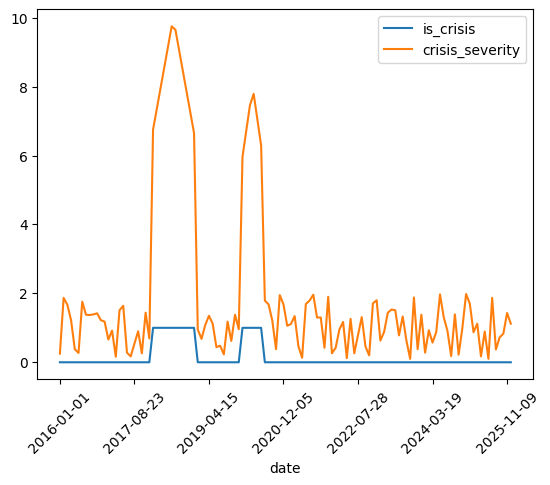

In [7]:
crisis_labels.plot(x="date", rot=45)

In [8]:
market_data = pd.read_csv("C:\\Users\\E15\\OneDrive\\Documents\\GitHub\\Financial-crisis-early-warning\\data\\raw\\market_data.csv")
market_data

,date,vix_index,credit_spread,yield_curve_slope,sp500_return,sp500_price,gdp_growth,unemployment_rate
0,2016-01-01,14.81,198.0,1.962,1.82,2036.39,2.26,5.76
1,2016-01-31,14.65,219.6,1.457,-0.40,2028.34,3.25,4.81
2,2016-03-01,14.58,154.6,1.475,1.14,2051.57,2.93,5.09
3,2016-03-31,14.97,163.8,1.489,-0.09,2049.79,3.98,4.64
4,2016-04-30,15.11,150.8,1.505,0.95,2069.25,1.98,5.89
...,...,...,...,...,...,...,...,...
117,2025-08-11,18.52,144.8,1.425,0.33,1961.72,1.90,3.57
118,2025-09-10,18.21,143.7,1.179,-1.14,1939.28,1.54,5.49
119,2025-10-10,18.44,159.0,1.412,-0.07,1937.86,2.40,3.57
120,2025-11-09,18.66,206.8,1.945,2.03,1977.24,3.17,5.44


In [9]:
market_lableled = pd.merge(market_data, crisis_labels, on="date", how="left")
market_lableled

,date,vix_index,credit_spread,yield_curve_slope,sp500_return,sp500_price,gdp_growth,unemployment_rate,is_crisis,crisis_severity
0,2016-01-01,14.81,198.0,1.962,1.82,2036.39,2.26,5.76,0,0.25
1,2016-01-31,14.65,219.6,1.457,-0.40,2028.34,3.25,4.81,0,1.87
2,2016-03-01,14.58,154.6,1.475,1.14,2051.57,2.93,5.09,0,1.67
3,2016-03-31,14.97,163.8,1.489,-0.09,2049.79,3.98,4.64,0,1.22
4,2016-04-30,15.11,150.8,1.505,0.95,2069.25,1.98,5.89,0,0.38
...,...,...,...,...,...,...,...,...,...,...
117,2025-08-11,18.52,144.8,1.425,0.33,1961.72,1.90,3.57,0,0.37
118,2025-09-10,18.21,143.7,1.179,-1.14,1939.28,1.54,5.49,0,0.72
119,2025-10-10,18.44,159.0,1.412,-0.07,1937.86,2.40,3.57,0,0.83
120,2025-11-09,18.66,206.8,1.945,2.03,1977.24,3.17,5.44,0,1.43


In [10]:
market_lableled.isnull().sum()

date                 0
vix_index            0
credit_spread        0
yield_curve_slope    0
sp500_return         0
sp500_price          0
gdp_growth           0
unemployment_rate    0
is_crisis            0
crisis_severity      0
dtype: int64

In [11]:
train_market_lableled = market_lableled[market_lableled["date"] < "2020-01-01"]
test_market_lableled = market_lableled[market_lableled["date"] >= "2020-01-01"]

In [12]:
exposures_network = pd.read_csv("C:\\Users\\E15\\OneDrive\\Documents\\GitHub\\Financial-crisis-early-warning\\data\\raw\\exposures_network.csv")
exposures_network

,date,creditor_id,debtor_id,exposure_amount,collateral_value,cds_spread
0,2016-01-01,INST0429,INST0018,1355.40,1044.63,41.6
1,2016-01-01,INST0068,INST0052,201.05,78.77,88.2
2,2016-01-01,INST0357,INST0337,30.33,23.67,84.8
3,2016-01-01,INST0199,INST0492,479.39,270.23,51.9
4,2016-01-01,INST0031,INST0466,2324.22,1621.41,184.5
...,...,...,...,...,...,...
143193,2025-12-09,INST0351,INST0088,669.31,251.65,75.4
143194,2025-12-09,INST0161,INST0216,226.20,99.24,126.6
143195,2025-12-09,INST0427,INST0428,5812.29,3658.98,149.6
143196,2025-12-09,INST0447,INST0487,26.85,11.00,84.6


In [13]:
train_exposures_network = exposures_network[exposures_network["date"] < "2020-01-01"]
test_exposures_network = exposures_network[exposures_network["date"] >= "2020-01-01"]

In [14]:
train_exposures_network_grouped = train_exposures_network.groupby("date")[["exposure_amount", "collateral_value", "cds_spread"]].sum()
test_exposures_network_grouped = test_exposures_network.groupby("date")[["exposure_amount", "collateral_value", "cds_spread"]].sum()

In [15]:
train_exposures_network_grouped.isnull().sum(),test_exposures_network_grouped.isnull().sum()

(exposure_amount     0
 collateral_value    0
 cds_spread          0
 dtype: int64,
 exposure_amount     0
 collateral_value    0
 cds_spread          0
 dtype: int64)

In [16]:
train_market_label_exposure = pd.merge(train_market_lableled, train_exposures_network_grouped, on="date", how="left")
test_market_label_exposure = pd.merge(test_market_lableled, test_exposures_network_grouped, on="date", how="left")

In [17]:
institution_metrics = pd.read_csv("C:\\Users\\E15\\OneDrive\\Documents/GitHub/Financial-crisis-early-warning\\data\\raw\\institution_metrics.csv")
institution_metrics

,date,institution_id,institution_type,total_assets,leverage_ratio,liquidity_ratio,roe,credit_rating,stock_price,cds_spread
0,2016-01-01,INST0001,Insurer,6153.31,7.30,0.084,0.0886,7.9,90.48,157.6
1,2016-01-01,INST0002,Broker,126038.37,15.20,0.349,0.1875,3.9,90.48,285.2
2,2016-01-01,INST0003,HedgeFund,15999.96,12.31,0.087,0.0878,5.3,90.48,244.4
3,2016-01-01,INST0004,HedgeFund,1114.83,10.40,0.338,0.0694,6.3,90.48,209.8
4,2016-01-01,INST0005,Bank,557.22,10.24,0.304,0.0694,6.4,90.48,211.1
...,...,...,...,...,...,...,...,...,...,...
60995,2025-12-09,INST0496,Insurer,1428.18,13.29,0.345,0.1751,4.9,516.16,253.2
60996,2025-12-09,INST0497,HedgeFund,2740.49,8.65,0.331,0.0644,7.2,171.65,148.0
60997,2025-12-09,INST0498,Bank,55072.36,13.95,0.250,-0.0326,4.5,65.42,291.7
60998,2025-12-09,INST0499,Broker,22042.40,9.43,0.285,0.1889,6.8,592.10,213.7


In [18]:
train_institution_metrics = institution_metrics[institution_metrics["date"] < "2020-01-01"]
test_institution_metrics = institution_metrics[institution_metrics["date"] >= "2020-01-01"]

In [19]:
train_institution_metrics_grouped = train_institution_metrics.groupby("date")[["total_assets", "leverage_ratio", "liquidity_ratio", "roe", "credit_rating", "stock_price", "cds_spread"]].mean()
test_institution_metrics_grouped = test_institution_metrics.groupby("date")[["total_assets", "leverage_ratio", "liquidity_ratio", "roe", "credit_rating", "stock_price", "cds_spread"]].mean()

In [20]:
train_institution_metrics_grouped.isnull().sum(),test_institution_metrics_grouped.isnull().sum()

(total_assets       0
 leverage_ratio     0
 liquidity_ratio    0
 roe                0
 credit_rating      0
 stock_price        0
 cds_spread         0
 dtype: int64,
 total_assets       0
 leverage_ratio     0
 liquidity_ratio    0
 roe                0
 credit_rating      0
 stock_price        0
 cds_spread         0
 dtype: int64)

In [21]:
train_market_label_exposure_institution = pd.merge(train_market_label_exposure, train_institution_metrics_grouped, on="date", how="left")
test_market_label_exposure_institution = pd.merge(test_market_label_exposure, test_institution_metrics_grouped, on="date", how="left")

In [22]:
transactions = pd.read_csv("C:\\Users\\E15\\OneDrive\\Documents/GitHub/Financial-crisis-early-warning\\data\\raw\\transactions.csv")
transactions

,datetime,from_institution,to_institution,amount,transaction_type
0,2022-08-27 03:59:00,INST0374,INST0236,3.31,derivative
1,2022-08-27 09:53:00,INST0194,INST0041,1.95,derivative
2,2022-08-27 18:12:00,INST0322,INST0317,12.98,collateral
3,2022-08-27 21:14:00,INST0361,INST0036,65.46,payment
4,2022-08-27 07:55:00,INST0396,INST0149,1.13,payment
...,...,...,...,...,...
50854,2018-09-17 08:12:00,INST0415,INST0367,120.66,payment
50855,2018-09-17 05:43:00,INST0475,INST0274,7.55,repo
50856,2018-09-17 00:58:00,INST0378,INST0069,7.76,payment
50857,2018-09-17 22:50:00,INST0456,INST0358,3.49,repo


In [23]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50859 entries, 0 to 50858
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          50859 non-null  str    
 1   from_institution  50859 non-null  str    
 2   to_institution    50859 non-null  str    
 3   amount            50859 non-null  float64
 4   transaction_type  50859 non-null  str    
dtypes: float64(1), str(4)
memory usage: 4.0 MB


In [24]:
transactions['date'] = pd.to_datetime(transactions['datetime']).dt.date
transactions.head()

,datetime,from_institution,to_institution,amount,transaction_type,date
0,2022-08-27 03:59:00,INST0374,INST0236,3.31,derivative,2022-08-27
1,2022-08-27 09:53:00,INST0194,INST0041,1.95,derivative,2022-08-27
2,2022-08-27 18:12:00,INST0322,INST0317,12.98,collateral,2022-08-27
3,2022-08-27 21:14:00,INST0361,INST0036,65.46,payment,2022-08-27
4,2022-08-27 07:55:00,INST0396,INST0149,1.13,payment,2022-08-27


In [25]:
train_transactions = transactions[transactions["date"] < pd.to_datetime("2020-01-01").date()]
test_transactions = transactions[transactions["date"] >= pd.to_datetime("2020-01-01").date()]

In [26]:
train_transactions_grouped = train_transactions.groupby("date", as_index=False).agg(
    amount=("amount", "sum"),
    transaction_type=("transaction_type", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

test_transactions_grouped = test_transactions.groupby("date", as_index=False).agg(
    amount=("amount", "sum"),
    transaction_type=("transaction_type", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

In [27]:
train_transactions_grouped.info(),test_transactions_grouped.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              21 non-null     object 
 1   amount            21 non-null     float64
 2   transaction_type  21 non-null     str    
dtypes: float64(1), object(1), str(1)
memory usage: 785.0+ bytes
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              29 non-null     object 
 1   amount            29 non-null     float64
 2   transaction_type  29 non-null     str    
dtypes: float64(1), object(1), str(1)
memory usage: 1.0+ KB


(None, None)

In [28]:
train_transactions_grouped['date'] = pd.to_datetime(train_transactions_grouped['date'])
test_transactions_grouped['date'] = pd.to_datetime(test_transactions_grouped['date'])
train_transactions_grouped.info(),test_transactions_grouped.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   date              21 non-null     datetime64[s]
 1   amount            21 non-null     float64      
 2   transaction_type  21 non-null     str          
dtypes: datetime64[s](1), float64(1), str(1)
memory usage: 785.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   date              29 non-null     datetime64[s]
 1   amount            29 non-null     float64      
 2   transaction_type  29 non-null     str          
dtypes: datetime64[s](1), float64(1), str(1)
memory usage: 1.0 KB


(None, None)

In [29]:
train_market_label_exposure_institution['date'] = pd.to_datetime(train_market_label_exposure_institution['date'])
test_market_label_exposure_institution['date'] = pd.to_datetime(test_market_label_exposure_institution['date'])
train_market_label_exposure_institution.info(), test_market_label_exposure_institution.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               49 non-null     datetime64[us]
 1   vix_index          49 non-null     float64       
 2   credit_spread      49 non-null     float64       
 3   yield_curve_slope  49 non-null     float64       
 4   sp500_return       49 non-null     float64       
 5   sp500_price        49 non-null     float64       
 6   gdp_growth         49 non-null     float64       
 7   unemployment_rate  49 non-null     float64       
 8   is_crisis          49 non-null     int64         
 9   crisis_severity    49 non-null     float64       
 10  exposure_amount    49 non-null     float64       
 11  collateral_value   49 non-null     float64       
 12  cds_spread_x       49 non-null     float64       
 13  total_assets       49 non-null     float64       
 14  leverage_ratio     49 n

(None, None)

In [30]:
train_final_df = pd.merge(train_market_label_exposure_institution, train_transactions_grouped, on='date', how='left')
test_final_df = pd.merge(test_market_label_exposure_institution, test_transactions_grouped, on='date', how='left')

In [31]:
missing_values_train = train_final_df.isnull().sum()
missing_values_test = test_final_df.isnull().sum()
percentage_missing_train = (missing_values_train / len(train_final_df)) * 100
percentage_missing_test = (missing_values_test / len(test_final_df)) * 100

missing_info_train = pd.DataFrame({
    'Missing Values': missing_values_train,
    'Percentage': percentage_missing_train
})
missing_info_test = pd.DataFrame({
    'Missing Values': missing_values_test,
    'Percentage': percentage_missing_test
})
missing_info_train = missing_info_train[missing_info_train['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_info_test = missing_info_test[missing_info_test['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

display(missing_info_train),display(missing_info_test)

,Missing Values,Percentage
amount,28,57.142857
transaction_type,28,57.142857


,Missing Values,Percentage
amount,44,60.273973
transaction_type,44,60.273973


(None, None)

In [32]:
train_final_df = train_final_df.sort_index()
train_final_df = train_final_df.set_index('date')

test_final_df = test_final_df.sort_index()
test_final_df = test_final_df.set_index('date')

In [33]:
train_final_df_imputed = train_final_df.copy()
test_final_df_imputed = test_final_df.copy()
train_final_df_imputed['amount'] = train_final_df_imputed['amount'].interpolate(method='linear', limit_direction='both')
test_final_df_imputed['amount'] = test_final_df_imputed['amount'].interpolate(method='linear', limit_direction='both')

most_frequent_transaction_type_train = train_final_df['transaction_type'].mode()[0]
most_frequent_transaction_type_test = test_final_df['transaction_type'].mode()[0]
train_final_df_imputed['transaction_type'] = train_final_df_imputed['transaction_type'].fillna(most_frequent_transaction_type_train)
test_final_df_imputed['transaction_type'] = test_final_df_imputed['transaction_type'].fillna(most_frequent_transaction_type_test)

train_final_df_imputed.isnull().sum()[['amount', 'transaction_type']],test_final_df_imputed.isnull().sum()[['amount', 'transaction_type']]

(amount              0
 transaction_type    0
 dtype: int64,
 amount              0
 transaction_type    0
 dtype: int64)

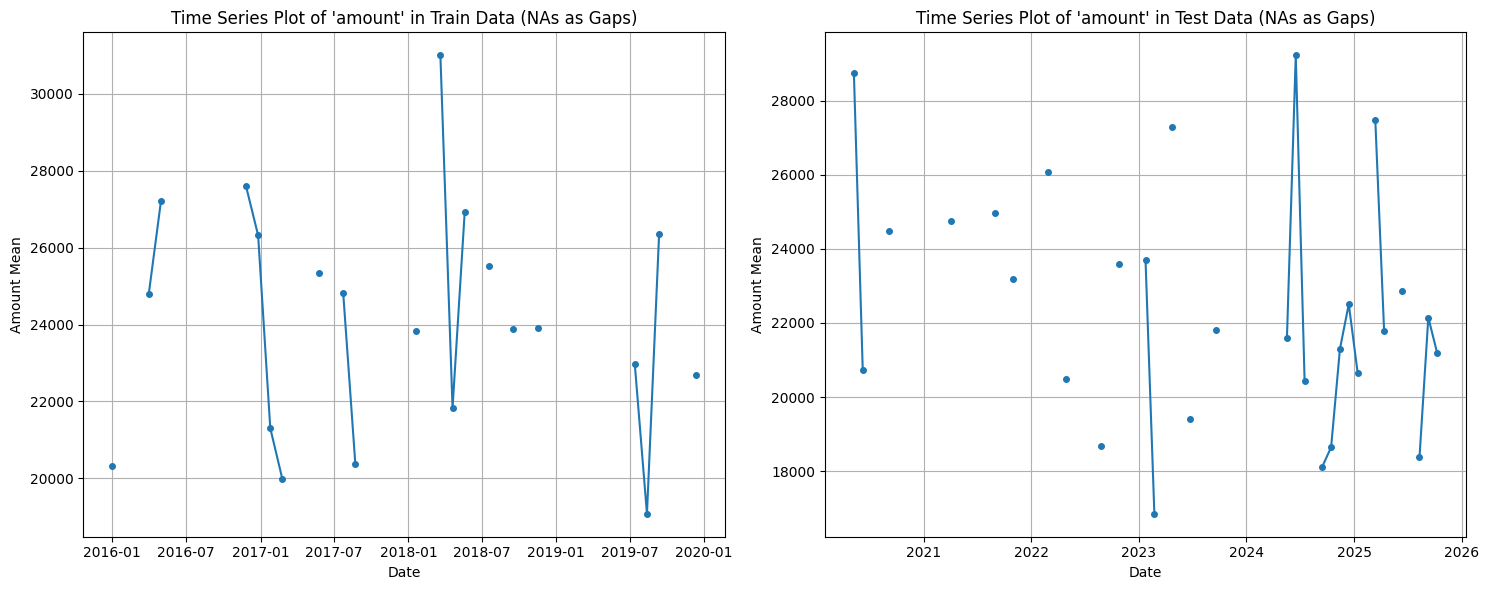

In [34]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(train_final_df['amount'], marker='o', linestyle='-', markersize=4)
plt.title('Time Series Plot of \'amount\' in Train Data (NAs as Gaps)')
plt.xlabel('Date')
plt.ylabel('Amount Mean')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_final_df['amount'], marker='o', linestyle='-', markersize=4)
plt.title('Time Series Plot of \'amount\' in Test Data (NAs as Gaps)')
plt.xlabel('Date')
plt.ylabel('Amount Mean')
plt.grid(True)

plt.tight_layout()
plt.show()

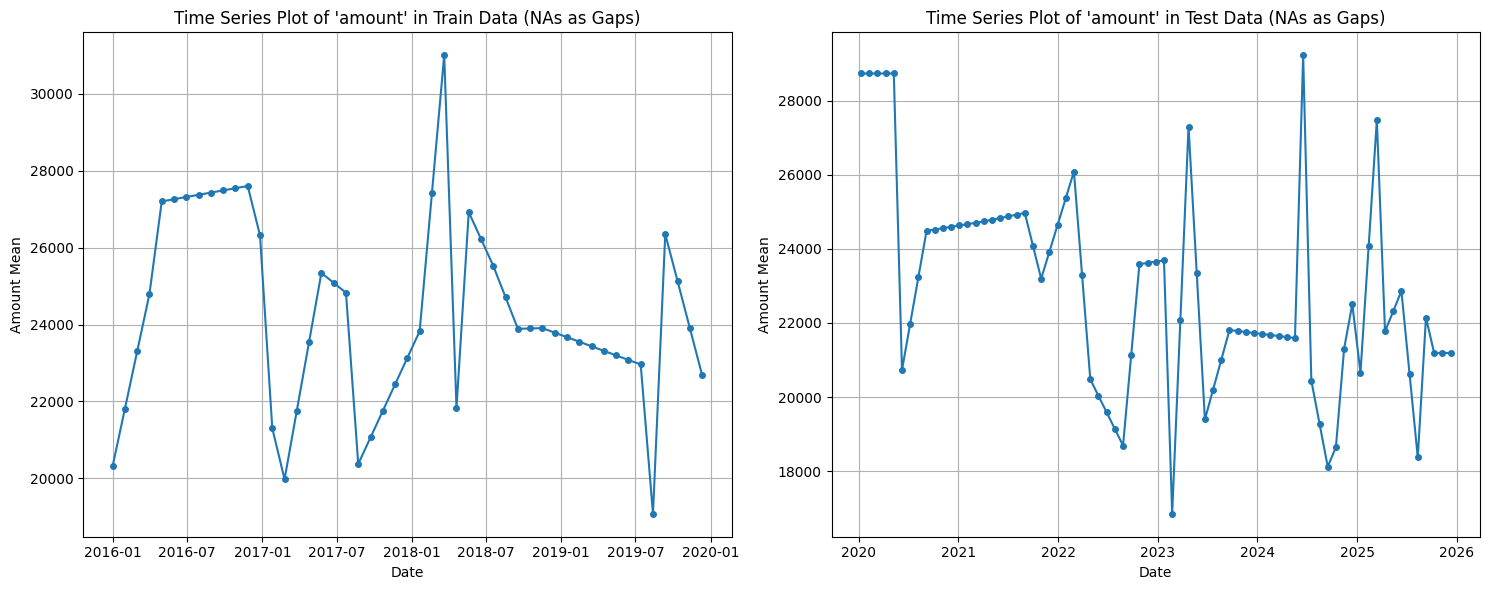

In [35]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(train_final_df_imputed['amount'], marker='o', linestyle='-', markersize=4)
plt.title('Time Series Plot of \'amount\' in Train Data (NAs as Gaps)')
plt.xlabel('Date')
plt.ylabel('Amount Mean')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_final_df_imputed['amount'], marker='o', linestyle='-', markersize=4)
plt.title('Time Series Plot of \'amount\' in Test Data (NAs as Gaps)')
plt.xlabel('Date')
plt.ylabel('Amount Mean')
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
df = pd.concat([train_final_df_imputed, test_final_df_imputed], axis=0)
df[['transaction_type','is_crisis']] = df[['transaction_type','is_crisis']].astype('category')
df[['is_crisis_before_3m', 'crisis_severity_before_3m']] = df[['is_crisis', 'crisis_severity']].shift(3)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 122 entries, 2016-01-01 to 2025-12-09
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   vix_index                  122 non-null    float64 
 1   credit_spread              122 non-null    float64 
 2   yield_curve_slope          122 non-null    float64 
 3   sp500_return               122 non-null    float64 
 4   sp500_price                122 non-null    float64 
 5   gdp_growth                 122 non-null    float64 
 6   unemployment_rate          122 non-null    float64 
 7   is_crisis                  122 non-null    category
 8   crisis_severity            122 non-null    float64 
 9   exposure_amount            122 non-null    float64 
 10  collateral_value           122 non-null    float64 
 11  cds_spread_x               122 non-null    float64 
 12  total_assets               122 non-null    float64 
 13  leverage_ratio             

In [37]:
df['is_crisis_before_3m'] = df['is_crisis_before_3m'].fillna(0).astype('int')
df['crisis_severity_before_3m'] = df['crisis_severity_before_3m'].fillna(random.randint(0, 2))
df

,vix_index,credit_spread,yield_curve_slope,sp500_return,sp500_price,gdp_growth,unemployment_rate,is_crisis,crisis_severity,exposure_amount,...,leverage_ratio,liquidity_ratio,roe,credit_rating,stock_price,cds_spread_y,amount,transaction_type,is_crisis_before_3m,crisis_severity_before_3m
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,14.81,198.0,1.962,1.82,2036.39,2.26,5.76,0,0.25,2330071.20,...,9.08300,0.226388,0.099467,6.9568,90.48000,179.0582,20315.39,collateral,0,1.00
2016-01-31,14.65,219.6,1.457,-0.40,2028.34,3.25,4.81,0,1.87,2272455.00,...,9.07012,0.225876,0.099353,6.9642,91.22794,179.0636,21808.76,payment,0,1.00
2016-03-01,14.58,154.6,1.475,1.14,2051.57,2.93,5.09,0,1.67,2696526.98,...,9.11522,0.226518,0.098817,6.9404,91.97528,183.0056,23302.13,payment,0,1.00
2016-03-31,14.97,163.8,1.489,-0.09,2049.79,3.98,4.64,0,1.22,2536693.78,...,9.02386,0.226040,0.098897,6.9876,92.73948,179.7504,24795.50,repo,0,0.25
2016-04-30,15.11,150.8,1.505,0.95,2069.25,1.98,5.89,0,0.38,2031049.02,...,9.05680,0.226266,0.099126,6.9730,93.51994,182.4986,27201.70,derivative,0,1.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-11,18.52,144.8,1.425,0.33,1961.72,1.90,3.57,0,0.37,2236184.81,...,9.09008,0.225918,0.097596,6.9516,309.31128,180.8532,18369.64,payment,0,0.89
2025-09-10,18.21,143.7,1.179,-1.14,1939.28,1.54,5.49,0,0.72,2340890.97,...,9.11742,0.225012,0.099476,6.9386,314.51726,182.6488,22145.39,repo,0,0.10
2025-10-10,18.44,159.0,1.412,-0.07,1937.86,2.40,3.57,0,0.83,2427393.79,...,9.02990,0.226548,0.098333,6.9836,315.70836,179.5748,21190.15,collateral,0,1.87


In [38]:
train_df = df[df.index < pd.to_datetime("2020-01-01")]
test_df = df[df.index >= pd.to_datetime("2020-01-01")]

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import (
    RandomForestClassifier,VotingClassifier, StackingClassifier,RandomForestRegressor
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc,
    confusion_matrix, classification_report,
    mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

In [40]:
X_train = train_df.drop(columns=['is_crisis', 'crisis_severity','is_crisis_before_3m', 'crisis_severity_before_3m'])
y_train = train_df['is_crisis_before_3m']
y_train_sev = train_df['crisis_severity_before_3m']

X_test = test_df.drop(columns=['is_crisis', 'crisis_severity','is_crisis_before_3m', 'crisis_severity_before_3m'])
y_test = test_df['is_crisis_before_3m']
y_test_sev = test_df['crisis_severity_before_3m']

In [41]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

In [42]:
# For tree models → NO scaling
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# For linear models → scaling + OHE
preprocessor_linear = ColumnTransformer([
    ('num', RobustScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


In [43]:
# --- Tree-based ---
rf_pipe = Pipeline([
    ('prep', preprocessor_tree),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))
])

xgb_pipe = Pipeline([
    ('prep', preprocessor_tree),
    ('model', XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    ))
])

lgbm_pipe = Pipeline([
    ('prep', preprocessor_tree),
    ('model', LGBMClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        num_leaves=7, class_weight='balanced',
        random_state=42, verbosity=-1
    ))
])

cat_pipe = Pipeline([
    ('prep', preprocessor_tree),
    ('model', CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05, verbose=0, random_state=42,))
])

In [44]:
# --- Linear models ---
lr_pipe = Pipeline([
    ('prep', preprocessor_linear),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

svc_pipe = Pipeline([
    ('prep', preprocessor_linear),
    ('model', SVC(probability=True, class_weight='balanced', kernel='rbf', random_state=42))
])

In [45]:
# Ensemble models
# =============================

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_pipe),
        ('xgb', xgb_pipe),
        ('lgbm', lgbm_pipe),
        ('cat', cat_pipe)
    ],
    voting='soft'
)

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf_pipe),
        ('xgb', xgb_pipe),
        ('lgbm', lgbm_pipe)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=3,
    n_jobs=-1,
    passthrough=False
)

classification_models = {
    'RandomForest': rf_pipe,
    'LogisticRegression': lr_pipe,
    'SVC': svc_pipe,
    'XGBoost': xgb_pipe,
    'LightGBM': lgbm_pipe,
    'CatBoost': cat_pipe,
    'Voting': voting_clf,
    'Stacking': stacking_clf
}

In [46]:
# Regression pipelines
# =============================
severity_models = {
    'RandomForest': Pipeline([
        ('prep', preprocessor_tree),
        ('model', RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor_tree),
        ('model', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))
    ]),
    'LightGBM': Pipeline([
        ('prep', preprocessor_tree),
        ('model', LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
    ]),
    'CatBoost': Pipeline([
        ('prep', preprocessor_tree),
        ('model', CatBoostRegressor(iterations=200, depth=4, learning_rate=0.05, verbose=0, random_state=42))
    ])
}

In [47]:
# Train & Evaluate Classification
# =============================
print("=== SYSTEMIC CRISIS PREDICTION ===\n")

for name, model in classification_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"--- {name} ---")
    print(f"F1 Score: {f1:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n")

=== SYSTEMIC CRISIS PREDICTION ===

--- RandomForest ---
F1 Score: 0.2222
PR-AUC: 0.2805
[[65  2]
 [ 5  1]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        67
           1       0.33      0.17      0.22         6

    accuracy                           0.90        73
   macro avg       0.63      0.57      0.59        73
weighted avg       0.88      0.90      0.89        73



--- LogisticRegression ---
F1 Score: 0.0000
PR-AUC: 0.1055
[[67  0]
 [ 6  0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        67
           1       0.00      0.00      0.00         6

    accuracy                           0.92        73
   macro avg       0.46      0.50      0.48        73
weighted avg       0.84      0.92      0.88        73



--- SVC ---
F1 Score: 0.5000
PR-AUC: 0.3873
[[64  3]
 [ 3  3]]
              precision    recall  f1-score   support

           0       0.96      0.96     

c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

--- XGBoost ---
F1 Score: 0.5455
PR-AUC: 0.7966
[[65  2]
 [ 3  3]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        67
           1       0.60      0.50      0.55         6

    accuracy                           0.93        73
   macro avg       0.78      0.74      0.75        73
weighted avg       0.93      0.93      0.93        73





c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM ---
F1 Score: 0.4615
PR-AUC: 0.6652
[[63  4]
 [ 3  3]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95        67
           1       0.43      0.50      0.46         6

    accuracy                           0.90        73
   macro avg       0.69      0.72      0.70        73
weighted avg       0.91      0.90      0.91        73



--- CatBoost ---
F1 Score: 0.0000
PR-AUC: 0.3363
[[67  0]
 [ 6  0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        67
           1       0.00      0.00      0.00         6

    accuracy                           0.92        73
   macro avg       0.46      0.50      0.48        73
weighted avg       0.84      0.92      0.88        73





c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

--- Voting ---
F1 Score: 0.5000
PR-AUC: 0.4625
[[64  3]
 [ 3  3]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        67
           1       0.50      0.50      0.50         6

    accuracy                           0.92        73
   macro avg       0.73      0.73      0.73        73
weighted avg       0.92      0.92      0.92        73



--- Stacking ---
F1 Score: 0.0000
PR-AUC: 0.6631
[[67  0]
 [ 6  0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        67
           1       0.00      0.00      0.00         6

    accuracy                           0.92        73
   macro avg       0.46      0.50      0.48        73
weighted avg       0.84      0.92      0.88        73





c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

In [48]:
# Regression Evaluation
# =============================
print("=== CRISIS SEVERITY REGRESSION ===\n")

trained_regressors = {}

for name, model in severity_models.items():
    model.fit(X_train, y_train_sev)
    trained_regressors[name] = model

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test_sev, y_pred)
    r2 = r2_score(y_test_sev, y_pred)

    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}\n")

=== CRISIS SEVERITY REGRESSION ===

--- RandomForest ---
MSE: 2.3932
R²: 0.1826

--- XGBoost ---
MSE: 3.2060
R²: -0.0950

--- LightGBM ---
MSE: 6.9972
R²: -1.3899

--- CatBoost ---
MSE: 2.5640
R²: 0.1243



c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [49]:
best_clf = xgb_pipe   
best_reg = trained_regressors['RandomForest']

combined_preds = pd.DataFrame({
    'date': X_test.index,
    'is_crisis_pred': best_clf.predict(X_test),
    'is_crisis_proba': best_clf.predict_proba(X_test)[:,1],
    'crisis_severity_pred': best_reg.predict(X_test)
}).set_index('date')

print(combined_preds.head())

            is_crisis_pred  is_crisis_proba  crisis_severity_pred
date                                                             
2020-01-10               0         0.456582              3.836217
2020-02-09               1         0.614392              3.864869
2020-03-10               1         0.573594              3.929412
2020-04-09               1         0.840663              3.260074
2020-05-09               1         0.643984              4.029347


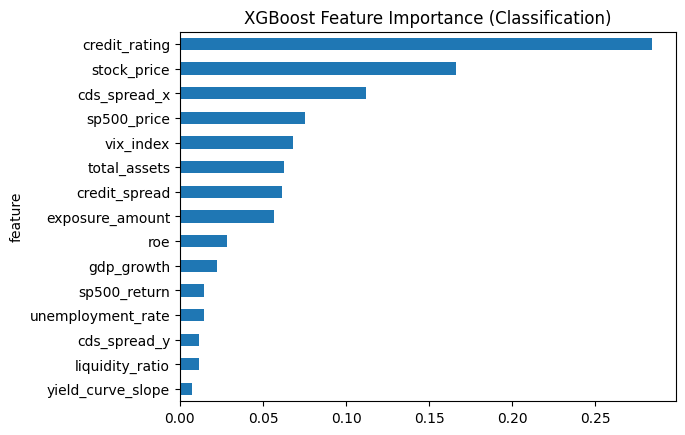

In [50]:
# extract model + preprocessing
preprocessor = best_clf.named_steps['prep']
xgb_model = best_clf.named_steps['model']

# transform data
X_transformed = preprocessor.transform(X_train)

# get feature names
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

ohe = preprocessor.named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_cols)

feature_names = list(numeric_cols) + list(cat_names)

# importance
importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# plot top 15
fi_df.head(15).plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False
)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Classification)")
plt.show()

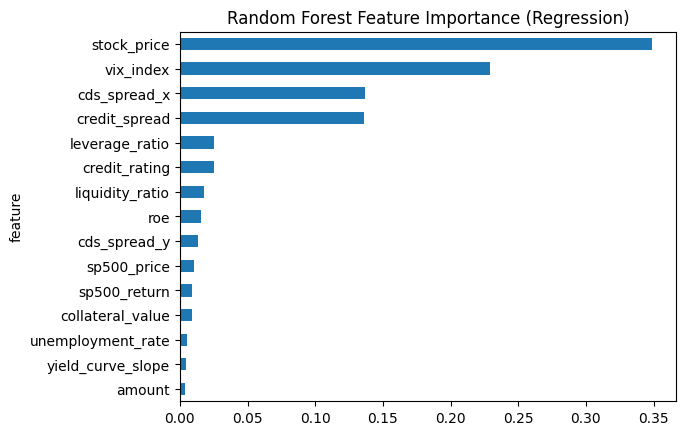

In [51]:
# extract model + preprocessing
preprocessor_reg = best_reg.named_steps['prep']
rf_model = best_reg.named_steps['model']

# transform data
X_transformed_reg = preprocessor_reg.transform(X_train)

# feature names
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

ohe_reg = preprocessor_reg.named_transformers_['cat']
cat_names = ohe_reg.get_feature_names_out(categorical_cols)

feature_names = list(numeric_cols) + list(cat_names)

# importance
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# plot top 15
fi_df.head(15).plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Regression)")
plt.show()

Generating SHAP explanations...


PermutationExplainer explainer: 74it [00:15,  4.59it/s]                        
C:\Users\E15\AppData\Local\Temp\ipykernel_12680\3377845561.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


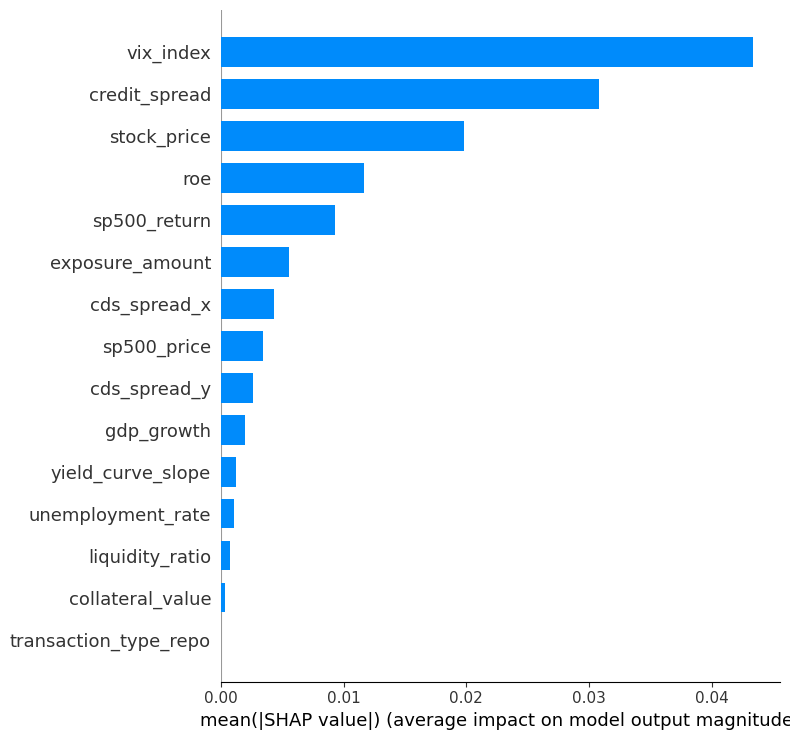

In [ ]:
print("Generating SHAP explanations...")

X_test_transformed = preprocessor.transform(X_test)

numeric_cols = X_test.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_test.select_dtypes(include=['object', 'category']).columns

ohe = preprocessor.named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_cols)

feature_names = np.concatenate([numeric_cols, cat_names])

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

explainer = shap.Explainer(xgb_model.predict_proba, X_test_transformed)
shap_values = explainer(X_test_transformed)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    plot_type="bar",
    max_display=15
)

Generating SHAP explanations...


c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, b

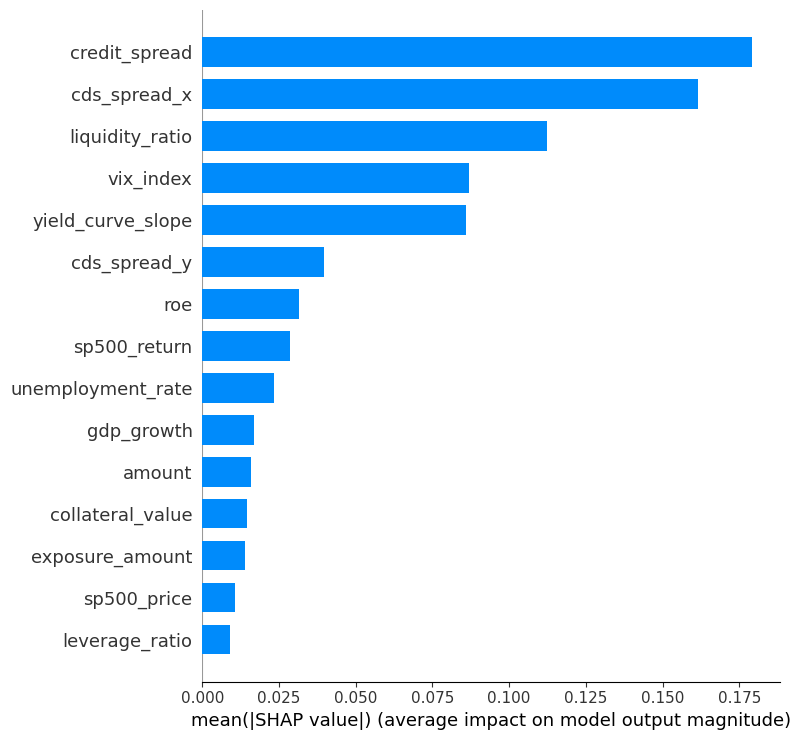

In [55]:
print("Generating SHAP explanations...")

X_test_transformed_reg = preprocessor_reg.transform(X_test)

X_test_transformed_reg = pd.DataFrame(
    X_test_transformed_reg,
    columns=feature_names
)

explainer = shap.Explainer(rf_model.predict, X_test_transformed_reg)
shap_values = explainer(X_test_transformed_reg)

shap.summary_plot(
    shap_values,
    X_test_transformed_reg,
    plot_type="bar",
    max_display=15
)

In [56]:
joblib.dump(best_clf, "best_clf_xgboost.pkl")
print("Classification model saved.")

Classification model saved.


In [57]:
joblib.dump(best_reg, "best_reg_rf.pkl")
print("Regression model saved.")

Regression model saved.
